In [66]:
from utils.dynamicRieszFunctions import estimateDynamicRiesz_all
from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiDLinear import estimateDiDLinear
import torch
import pandas as pd
import time
from torch.distributions import Normal
from utils.dgp import DiD_DGP
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


## Settings


In [67]:
lasso_cv_settings = {
    'b_degree' : 1,
    'cv_folds' : 5,
    'random_state' : 42
}

lasso_a_settings = {
    'lambda_val' : 0,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' : "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

lasso_f_settings = {
    'lambda_val' : 0,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' :  "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

rf_a_settings = {
    'poly_degree' : 0,
    'l2' : 0,
    'n_estimators' : 100,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 4,
    'n_jobs' : -1,
    'random_state' : None,
    'verbose' : 0,
    'warm_start' : False
}
rf_f_settings = {
    'poly_degree' : 1, # 1 or 2?
    'l2' : 0,
    'n_estimators' : 100,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 4,
    'n_jobs' : -1,
    'random_state' : None,
    'verbose' : 0,
    'warm_start' : False
}

net_a_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}

net_f_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}


## Coefficients and Parameters

In [68]:
# Parameters
N = 1000
tmax = 100
dimX = 3
dimZ = 2
seed = 123
folds = 5

## Propensity models 

In [69]:
# Bounds (only for truncated distributions)
lower = 0.30
upper = 0.70

# Define logistic function
def logistic(x):
    return torch.exp(x) / (1 + torch.exp(x))

# Define a truncated logistic function
def truncated_logistic(x):
    return lower + (upper - lower) * logistic(x)

# Simple nonlinear probability (from adversarial Riesz paper)
def truncated_adv(x):
    return lower + (upper - lower) * (x > 0)


## Generate data

In [ ]:
dgp = DiD_DGP(dim_X=dimX, dim_Z=dimZ, 
                alpha_1 = 1, # Y_1s effect on D
              gamma_1=torch.ones(dimZ), # Z effect on D
                gamma_2=torch.ones(dimZ), # Z effect on Y
                g = truncated_logistic, # specification of the propensity modek
                beta_2=2
                delta_3= 2 
                )

data = dgp.generate(n =N*tmax, seed = seed)
X1 = data['X1']
X2 = data['X2']
Y1 = data['Y1']
Y2 = data['Y2']
Z = data['Z']
D = data['D']


In [71]:
ATT_calculations = dgp.simulate_ATT(n = 100000000)


In [72]:
ATT_calculations["ATT"]

tensor(3.8155)

In [73]:
print(X1.shape)
print(X2.shape)
print(Y1.shape)
print(Y2.shape)
print(Z.shape)
print(D.shape)

torch.Size([100000, 3])
torch.Size([100000, 3])
torch.Size([100000])
torch.Size([100000])
torch.Size([100000, 2])
torch.Size([100000])


In [74]:
print(D.mean())

tensor(0.5335)


In [75]:
# Naive ATT estimate
Y2[D==1].mean() - Y2[D==0].mean()

tensor(5.4337)

## Estimation

In [76]:
time0 = time.time()
pred_theta = torch.zeros(tmax,5)
pred_sig = torch.zeros(tmax,5)

RR1 = torch.zeros(N,tmax,5)
RR2 = torch.zeros(N,tmax,5)
f1 = torch.zeros(N,tmax,5)
f2 = torch.zeros(N,tmax,5)

for t in tqdm(range(0,tmax)):

    # Get data for current iteration
    X1_sub = X1[t*N:(t+1)*N,:]
    X2_sub = X2[t*N:(t+1)*N,:]
    Y1_sub = Y1[t*N:(t+1)*N].view(-1, 1)
    Y2_sub = Y2[t*N:(t+1)*N].view(-1, 1)
    D_sub = D[t*N:(t+1)*N].view(-1, 1)
    Z_sub = Z[t*N:(t+1)*N,:]


    pred_theta[t,1], pred_sig[t,1] = estimateDiDLinear(Y1_sub, Y2_sub, D_sub, Z_sub, X1_sub  , X2_sub)

    pred_theta[t,3], pred_sig[t,3], RR1[:,t,3:4], RR2[:,t,3:4] = estimateDynamicRiesz(Y1_sub, Y2_sub, D_sub, Z_sub, X1_sub  , X2_sub, folds,
                                                                     method_a = "RF", rf_a_settings=rf_a_settings,
                                                                        method_f = "RF", rf_f_settings = rf_f_settings)





100%|██████████| 100/100 [06:06<00:00,  3.67s/it]


In [77]:
pred_theta[:,3] 

tensor([3.7495, 3.7451, 3.7731, 3.6938, 4.2062, 3.8165, 3.5900, 3.7015, 3.8250,
        3.8484, 3.7699, 3.9811, 3.9197, 3.9217, 3.7654, 3.7120, 4.0082, 3.9088,
        4.0115, 3.7503, 3.8474, 3.7268, 3.7233, 3.8373, 3.6299, 3.9158, 3.6733,
        4.0921, 3.7501, 3.8528, 3.9660, 3.4708, 3.4713, 3.9898, 3.7125, 3.8446,
        3.9130, 3.8188, 3.8472, 3.9901, 3.6552, 3.2552, 3.7406, 3.5414, 3.8329,
        4.1600, 3.9323, 3.8432, 3.6755, 3.7288, 4.0306, 3.6594, 3.8219, 3.7779,
        4.0981, 3.7379, 3.9674, 3.9889, 3.7199, 3.2178, 3.7505, 3.7056, 3.9198,
        4.2077, 3.6527, 3.8136, 3.7914, 3.6223, 3.8577, 3.9112, 4.0154, 3.9783,
        3.8154, 3.5405, 3.6587, 4.0728, 3.5778, 3.9361, 3.8596, 4.1724, 4.0115,
        3.9707, 3.7517, 3.9078, 4.2606, 3.9047, 3.9559, 3.6732, 3.6947, 3.8897,
        3.7963, 3.9142, 3.6476, 3.8573, 3.7084, 4.0153, 3.8776, 3.7721, 3.6635,
        3.5318])

In [78]:
pred_theta[:,1] 

tensor([3.7599, 3.6167, 3.7303, 3.6991, 4.0958, 3.6925, 3.4847, 3.6763, 3.7409,
        3.7268, 3.7661, 3.9568, 3.9042, 3.8490, 3.7739, 3.7112, 3.9055, 3.8948,
        3.9492, 3.6844, 3.7702, 3.7205, 3.6369, 3.8044, 3.5039, 3.7710, 3.6430,
        4.0182, 3.7304, 3.8760, 3.9490, 3.3059, 3.4499, 3.8665, 3.6534, 3.7424,
        3.9236, 3.7003, 3.8241, 3.8257, 3.6092, 3.2210, 3.7513, 3.4653, 3.7131,
        3.9766, 3.8480, 3.8150, 3.5606, 3.6666, 3.9731, 3.5318, 3.8176, 3.6412,
        3.9623, 3.6833, 3.9584, 3.9212, 3.6086, 3.1568, 3.5902, 3.6872, 3.8778,
        4.2142, 3.6525, 3.7810, 3.7686, 3.4505, 3.8336, 3.8716, 3.8785, 3.8911,
        3.7754, 3.5327, 3.6917, 3.8934, 3.5622, 3.8080, 3.7570, 4.1650, 4.0201,
        3.9317, 3.7045, 3.9008, 4.1852, 3.8081, 3.9227, 3.5889, 3.5870, 3.8857,
        3.7907, 3.8766, 3.5224, 3.8445, 3.7049, 3.9935, 3.8611, 3.7838, 3.5473,
        3.5019])

In [79]:
print(torch.sqrt(torch.mean((pred_theta[:,3] - ATT_calculations["ATT"])**2)))

tensor(0.1815)


In [80]:
print(torch.sqrt(torch.mean((pred_theta[:,1] - ATT_calculations["ATT"])**2)))

tensor(0.1938)


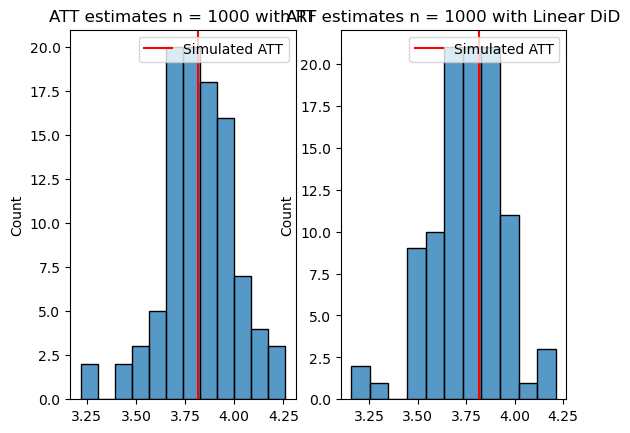

In [81]:
fig, ax = plt.subplots(1,2)
sns.histplot(pred_theta[:, 3], ax = ax[0])
ax[0].axvline(x=ATT_calculations["ATT"], color="red", label="Simulated ATT")
ax[0].set_title("ATT estimates n = 1000 with RF")
ax[0].legend()#
sns.histplot(pred_theta[:, 1], ax = ax[1])
ax[1].axvline(x=ATT_calculations["ATT"], color="red", label="Simulated ATT")
ax[1].set_title("ATT estimates n = 1000 with Linear DiD")
ax[1].legend()#
plt.show()

## Application

In [ ]:
from utils.application import *#
data_apllication = application_data()

In [ ]:
data_dict = data_apllication.get_data(2003, 2004 )

Changing covariates:  ['emp0A01_BS', 'pop', 'annual_avg_pay', 'lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', 'censusdiv_3', 'censusdiv_4', 'censusdiv_5', 'censusdiv_6', 'censusdiv_7', 'censusdiv_8']


In [ ]:
X1 = data_dict['X1']
X2 = data_dict['X2']
Y1 = data_dict['Y1']
Y2 = data_dict['Y2']
D = data_dict['D']
Z = data_dict['Z']  

In [ ]:
D.sum()

tensor(102.)

In [ ]:
X1.shape

torch.Size([2491, 5])

In [ ]:
estimateDynamicRiesz(Y1, Y2, D, Z, X1, X2, folds,
                                                                     method_a = "RF", rf_a_settings=rf_a_settings,
                                                                        method_f = "RF", rf_f_settings = rf_f_settings)

(tensor(-0.0089),
 tensor(0.7505),
 tensor([[1.0691],
         [1.0460],
         [1.0492],
         ...,
         [1.0429],
         [1.0494],
         [1.0671]]),
 tensor([[1.0561],
         [1.0377],
         [1.0472],
         ...,
         [1.0393],
         [1.0427],
         [1.0567]]))

In [ ]:
test =pd.read_csv("https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/minwage_data.csv", index_col=0)

In [ ]:
Z = test[test["year"] == 2003][["region", "censusdiv"]].reset_index(drop=True)

test["region"].value_counts()

region
3    7469
2    7301
4    2730
1    1351
Name: count, dtype: int64

In [ ]:
Z["region"].value_counts()

region
3    1067
2    1043
4     390
1     193
Name: count, dtype: int64

In [ ]:
Z["censusdiv"].value_counts()

censusdiv
4    606
5    584
3    437
7    388
8    234
9    156
2    150
6     95
1     43
Name: count, dtype: int64